In [1]:
torch_device = "cuda:0"

In [21]:
# m is the LDM metadata
# e is the embedding
# r is the random bit
import json
import hmac
import hashlib
import pickle

m = {"model_id" : "stabilityai/stable-diffusion-2-1", "timesteps": 10}
def construct_POA(m, e, r, author_id = "1"):
    m = pickle.dumps(m)
    e = pickle.dumps(e)
    
    signature = hmac.new(
        bytes("1", 'latin-1'), 
        msg=pickle.dumps((e, m, r)), 
        digestmod=hashlib.sha256
    ).hexdigest().upper()

    return signature [:8]

In [9]:
from datasets import load_dataset
train = [sample['Prompt'] for sample in load_dataset('Gustavosta/Stable-Diffusion-Prompts')['train']]

In [10]:
from diffusers import DDPMPipeline
from transformers import CLIPTextModel, CLIPTokenizer
from diffusers import AutoencoderKL, UNet2DConditionModel, PNDMScheduler, DDIMScheduler
from PIL import Image
import torch
from tqdm.auto import tqdm

model_id = "stabilityai/stable-diffusion-2-1"
# batch_size=10

vae = AutoencoderKL.from_pretrained(model_id , subfolder="vae", use_safetensors=True)
tokenizer = CLIPTokenizer.from_pretrained(model_id , subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(
    model_id , subfolder="text_encoder", use_safetensors=True
)
unet = UNet2DConditionModel.from_pretrained(
    model_id , subfolder="unet", use_safetensors=True
)

vae.to(torch_device)
text_encoder.to(torch_device)
unet.to(torch_device)

prompt= ['carrots with coffee']
batch_size=len(prompt)

text_input = tokenizer(
    prompt, padding="max_length", max_length=tokenizer.model_max_length, truncation=True, return_tensors="pt"
)

with torch.no_grad():
    text_embeddings = text_encoder(text_input.input_ids.to(torch_device))[0]


max_length = text_input.input_ids.shape[-1]
uncond_input = tokenizer([""] * batch_size, padding="max_length", max_length=max_length, return_tensors="pt")
uncond_embeddings = text_encoder(uncond_input.input_ids.to(torch_device))[0]
text_embeddings = torch.cat([uncond_embeddings, text_embeddings])

scheduler = DDIMScheduler.from_pretrained(model_id, subfolder="scheduler", batch_size=batch_size)


In [11]:
def convert_sentence_to_embed(lst_of_sentences):
    text_input = tokenizer(
        lst_of_sentences, padding="max_length", max_length=tokenizer.model_max_length, truncation=True, return_tensors="pt"
    )
    batch_size = len(lst_of_sentences)
    with torch.no_grad():
        text_embeddings = text_encoder(text_input.input_ids.to(torch_device))[0]
    
    
    max_length = text_input.input_ids.shape[-1]
    uncond_input = tokenizer([""] * batch_size, padding="max_length", max_length=max_length, return_tensors="pt")
    uncond_embeddings = text_encoder(uncond_input.input_ids.to(torch_device))[0]
    text_embeddings = torch.cat([uncond_embeddings, text_embeddings])
    return text_embeddings

import numpy as np
scheduler = DDIMScheduler.from_pretrained(model_id, subfolder="scheduler", batch_size=batch_size)
    
def get_vae_embed_from_text_embed(text_embed, seed=1, timesteps=10, 
                                  n_samples=1, batch_size=batch_size,
                                 guidance_scale = 7.5,
                                 same_seed=False,
                                 latents=None): # use same seed across all iteration 
    
    
    out = []
    scheduler.set_timesteps(timesteps)
    out_latent = []
     #seed is a 64 bit signed int
    generator = torch.manual_seed(seed)
    for _ in tqdm([i for i in range(n_samples)]):
        if same_seed:
            generator = torch.manual_seed(seed)
        if latents is None:
            latents = torch.randn(
                (batch_size, unet.config.in_channels, 512//8, 512//8),
                    generator=generator,
                )
        latents = latents.to(torch_device)
        latents = latents * scheduler.init_noise_sigma
        
        for t in tqdm(scheduler.timesteps):
            
            # expand the latents if we are doing classifier-free guidance to avoid doing two forward passes.
            latent_model_input = torch.cat([latents] * 2)
            latent_model_input = scheduler.scale_model_input(latent_model_input, timestep=t)

            # predict the noise residual
            with torch.no_grad():
                noise_pred = unet(latent_model_input, t, encoder_hidden_states=text_embed).sample

            # perform guidance
            noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
            noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)

            # compute the previous noisy sample x_t -> x_t-1
            latents = scheduler.step(noise_pred, t, latents).prev_sample
        # vae step
        latents = 1 / 0.18215 * latents
        out_latent.append(latents)
    return torch.cat(out_latent,dim=0).to(torch_device)

def latent_to_img(latents):
    with torch.no_grad():
        image = vae.decode(latents).sample
    np_image = np.array(image.cpu())
#         if height % 8 != 0 or width % 8 != 0:

        # np_image = cv2.resize(np.transpose(np_image, (0,2, 3, 1)), dsize=dim_wh, interpolation=cv2.INTER_LINEAR)
    # np_image = np.transpose(np_image, (0,3,1,2))
    return np_image
    #     out.extend(np_image)
    # return np.array(out)

In [14]:
n_image = 100

In [22]:
import copy
sd_ori_imgs = []
embeds = []
lat = []

for i in range(n_image):
    prompt_embed = convert_sentence_to_embed(train[i:i+1])
    latents = torch.randn(
                (batch_size, unet.config.in_channels, 512//8, 512//8),
                    generator = torch.manual_seed(int("0x" + construct_POA(m, prompt_embed, "1"), 16)),
                )
    lat.append(copy.deepcopy(latents))
    vae_embed = get_vae_embed_from_text_embed(prompt_embed, latents=latents)
    
    embeds.append(vae_embed)
    out_img = latent_to_img(vae_embed)
    sd_ori_imgs.append(out_img)

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

In [23]:
import copy
embeds_same_prompt_diff_seed = []
# lats_same_prompt_diff_seed = []
# n_image = 100
prompt_embed = convert_sentence_to_embed(train[0:1])
for i in range(n_image):
    latents = lat[i]
    # latents = torch.randn(
    #             (batch_size, unet.config.in_channels, 512//8, 512//8),
    #                 generator = torch.manual_seed(i),
    #             )
    # lats_same_prompt_diff_seed.append(latents)
    vae_embed = get_vae_embed_from_text_embed(prompt_embed, latents=latents)
    
    embeds_same_prompt_diff_seed.append(vae_embed)

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

In [24]:
def compute_pairwise_dist(arr):
    return [float(torch.sum((arr[i] - arr[j])**2)) for i in range(len(arr)) for j in range(i+1, len(arr))]
start_pairwise_dist = compute_pairwise_dist(lat)
same_prompt_pairwise_dist = compute_pairwise_dist(embeds_same_prompt_diff_seed)
diff_prompt_pairwise_dist = compute_pairwise_dist(embeds)

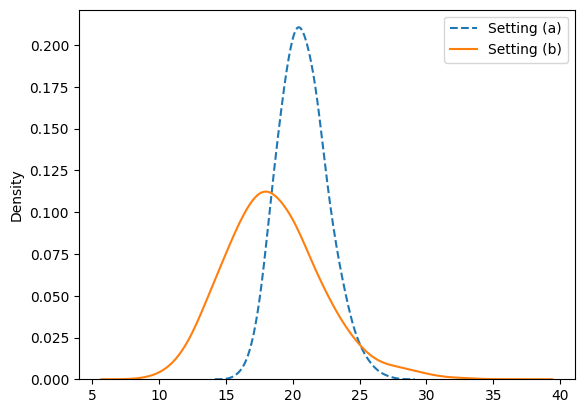

In [25]:
import seaborn as sb
import matplotlib.pyplot as plt
ratio_1 = [same_prompt_pairwise_dist[i]/start_pairwise_dist[i] for i in range(len(same_prompt_pairwise_dist))]
ratio_2 = [diff_prompt_pairwise_dist[i]/start_pairwise_dist[i] for i in range(len(same_prompt_pairwise_dist))]
sb.kdeplot(ratio_1, bw_adjust=1.5, label = "Setting (a)", linestyle = "--")
sb.kdeplot(ratio_2, bw_adjust=1.5, label = "Setting (b)")
plt.legend()
# plt.ylim()

In [26]:
import statistics
print(statistics.mean(ratio_1))
print(statistics.mean(ratio_2))

20.75659954058132
18.57625786128175


In [27]:
with torch.no_grad():
    pic = latent_to_img(vae_embed.to(torch_device))
    zz = vae.to(torch_device).encode(torch.from_numpy(pic).to(torch_device))

In [28]:
import copy
embeds_same_start_pt = []
# lat = []
latents = torch.randn(
            (batch_size, unet.config.in_channels, 512//8, 512//8),
                generator = torch.manual_seed(int("0x" + construct_POA(m, prompt_embed, "1"), 16)),
            )
# n_image = 100
for i in range(n_image):
    prompt_embed = convert_sentence_to_embed(train[i:i+1])

    vae_embed = get_vae_embed_from_text_embed(prompt_embed, latents=latents)
    
    embeds_same_start_pt.append(vae_embed)

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

In [29]:
import seaborn as sb
d=4*64*64
pairwise_vae_dist_same_start = [float(torch.sum((embeds_same_start_pt[i] - embeds_same_start_pt[j])**2))* 0.213215**2 /2 for i in range(len(embeds_same_start_pt)) for j in range(i+1, len(embeds_same_start_pt))]
pairwise_vae_dist_same_prompt = [float(torch.sum((embeds_same_prompt_diff_seed[i] - embeds_same_prompt_diff_seed[j])**2))* 0.213215**2 /2  for i in range(len(embeds_same_start_pt)) for j in range(i+1, len(embeds_same_start_pt))]



In [30]:
from torchvision import transforms as tfms

def get_vae_embed_from_image(orig_image):
    with torch.no_grad(): 
        latent = vae.to(torch_device).encode(orig_image)
        lat = 0.18215 * latent.latent_dist.sample()
    return lat

In [31]:
poa_dist_sq = []
for i in range(len(sd_ori_imgs)):
    emb = 0.215 * embeds[i]
    im = sd_ori_imgs[i]
    invert_embed = get_vae_embed_from_image(torch.from_numpy(im).to(torch_device))
    poa_dist_sq.append(torch.sum((invert_embed - emb)**2))

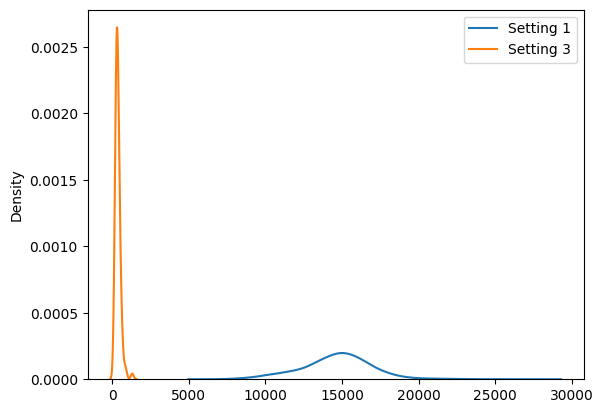

In [32]:
import seaborn as sb
d=4*64*64
pairwise_latent_dist = [ float(torch.sum((lat[i] - lat[j])**2)) * 0.213215**2 /2  for i in range(len(lat)) for j in range(i+1, len(lat))]
pairwise_vae_dist = [float(torch.sum((embeds[i] - embeds[j])**2))* 0.213215**2 /2  for i in range(len(embeds)) for j in range(i+1, len(embeds))]
import numpy as np
# chisq_rv = np.random.chisquare(d, size=len(pairwise_vae_dist))/d 


from math import *
# p = sb.regplot(x=pairwise_latent_dist, y=pairwise_vae_dist)
import matplotlib.pyplot as plt
sb.kdeplot(pairwise_vae_dist+pairwise_vae_dist_same_prompt, bw_adjust=1.4, label = "Setting 1") #Different Prompt & Starting
# sb.kdeplot(pairwise_vae_dist_same_start, bw_adjust=1.4, label = "Setting 2") # Different Prompt, Same Starting
# sb.kdeplot(pairwise_vae_dist_same_prompt, bw_adjust=1.4, label = "Setting 2") # Same Prompt, Different Starting
sb.kdeplot([float(i)/2 for i in poa_dist_sq], bw_adjust=1.4, label = "Setting 3") # Same POA
# sb.kdeplot(chisq_rv, label="\$\frac{1}{d} \chi^2_d \$")
# plt.axvline(x=0.25, color='r', linestyle='--', label='Vertical Line at x=5')
plt.legend()
# p.show()

In [33]:
import io
def jpeg_compress(image_arr, jpeg_quality=75):
    im_pil = Image.fromarray(image_arr.astype(np.uint8))
    buffered = io.BytesIO()
    im_pil.save(buffered, format="JPEG", quality=jpeg_quality, optimize=True)
    # compressed_image_data = buffered.getvalue()
    return np.array(Image.open(buffered))

In [34]:
vae_rep = []
vae_rep_gauss_1 = []
vae_rep_gauss_3 = []
vae_rep_gauss_5 = []
vae_rep_gauss_7 = []
vae_rep_gauss_9 = []
vae_rep_jpeg_75 = []
vae_rep_jpeg_50 = []
torch.manual_seed(1)
np.random.seed(1)
gauss_unit_noise = np.random.normal(size=sd_ori_imgs[-1].shape)
def normalize_image(im):
    return (im - np.min(im)) / (np.max(im) - np.min(im)) * 255

def reset_image(im, old_min, old_max):
    return im/255 * (old_max - old_min) + old_min
for i in sd_ori_imgs:
    with torch.no_grad():
        vae_rep.append(vae.to(torch_device).encode(torch.from_numpy(i).to(torch_device)))

        old_max, old_min = np.max(i), np.min(i)
        im_normalized = normalize_image(i)
        im_gauss_1 = im_normalized + gauss_unit_noise
        im_gauss_1 = reset_image(im_gauss_1, old_min, old_max)

        im_gauss_3 = im_normalized + gauss_unit_noise * 3**0.5
        im_gauss_3 = reset_image(im_gauss_3, old_min, old_max)

        im_gauss_5 = im_normalized + gauss_unit_noise * 5**0.5
        im_gauss_5 = reset_image(im_gauss_5, old_min, old_max)

        im_gauss_7 = im_normalized + gauss_unit_noise * 7**0.5
        im_gauss_7 = reset_image(im_gauss_7, old_min, old_max)

        im_gauss_9 = im_normalized + gauss_unit_noise * 9**0.5
        im_gauss_9 = reset_image(im_gauss_9, old_min, old_max)

        vae_rep_gauss_1.append(vae.to(torch_device).encode(torch.from_numpy(im_gauss_1.astype(np.float32)).to(torch_device)))
        vae_rep_gauss_3.append(vae.to(torch_device).encode(torch.from_numpy(im_gauss_3.astype(np.float32)).to(torch_device)))
        vae_rep_gauss_5.append(vae.to(torch_device).encode(torch.from_numpy(im_gauss_5.astype(np.float32)).to(torch_device)))
        vae_rep_gauss_7.append(vae.to(torch_device).encode(torch.from_numpy(im_gauss_7.astype(np.float32)).to(torch_device)))
        vae_rep_gauss_9.append(vae.to(torch_device).encode(torch.from_numpy(im_gauss_9.astype(np.float32)).to(torch_device)))

        # jpeg compression
        im_jpeg_75 = jpeg_compress(np.transpose(im_normalized[0],(1,2,0)), jpeg_quality=75)
        im_jpeg_75 = np.transpose(im_jpeg_75, (2, 0, 1))
        im_jpeg_75 = reset_image(im_jpeg_75, old_min, old_max)
        im_jpeg_75 = im_jpeg_75.reshape(im_normalized.shape)
        vae_rep_jpeg_75.append(vae.to(torch_device).encode(torch.from_numpy(im_jpeg_75.astype(np.float32)).to(torch_device)))

        im_jpeg_50 = jpeg_compress(np.transpose(im_normalized[0],(1,2,0)), jpeg_quality=20)
        im_jpeg_50 = np.transpose(im_jpeg_50, (2, 0, 1))
        im_jpeg_50 = reset_image(im_jpeg_50, old_min, old_max)
        im_jpeg_50 = im_jpeg_50.reshape(im_normalized.shape)
        vae_rep_jpeg_50.append(vae.to(torch_device).encode(torch.from_numpy(im_jpeg_50.astype(np.float32)).to(torch_device)))

In [35]:
def get_normlized_latent(lat):
    return lat/torch.std(lat)

T = lambda x, y: float(torch.sum(x*y))

test_stat = []
test_stat_gauss_1, test_stat_gauss_3,test_stat_gauss_5,test_stat_gauss_7, test_stat_gauss_9, test_stat_jpeg_50, test_stat_jpeg_75  = [], [], [], [], [], [], []
test_stat_wrong = []
for i in range(len(vae_rep)):
    # normalize both
    latent_1 = vae_rep[i].latent_dist.mean
    latent_2 = embeds[i]
    latent_1 = get_normlized_latent(latent_1)
    latent_2 = get_normlized_latent(latent_2)
    test_stat.append(T(latent_1, latent_2))

    latent_wrong = embeds[i-12]
    latent_wrong = latent_wrong/torch.std(latent_wrong)
    test_stat_wrong.append(float(torch.sum((latent_1 * latent_wrong))))


    
    # noisy latent 
    
    latent_gauss_1 = vae_rep_gauss_1[i].latent_dist.mean
    latent_gauss_1 = get_normlized_latent(latent_gauss_1 )
    test_stat_gauss_1.append(T(latent_gauss_1, latent_2))

    latent_gauss_3 = vae_rep_gauss_3[i].latent_dist.mean
    latent_gauss_3 = get_normlized_latent(latent_gauss_3 )
    test_stat_gauss_3.append(T(latent_gauss_3, latent_2))

    latent_gauss_5 = vae_rep_gauss_5[i].latent_dist.mean
    latent_gauss_5 = get_normlized_latent(latent_gauss_5)
    test_stat_gauss_5.append(T(latent_gauss_5, latent_2))

    latent_gauss_7 = vae_rep_gauss_7[i].latent_dist.mean
    latent_gauss_7 = get_normlized_latent(latent_gauss_7 )
    test_stat_gauss_7.append(T(latent_gauss_7, latent_2))

    latent_gauss_9 = vae_rep_gauss_9[i].latent_dist.mean
    latent_gauss_9 = get_normlized_latent(latent_gauss_9 )
    test_stat_gauss_9.append(T(latent_gauss_9, latent_2))

    latent_gauss_jpeg_50 = vae_rep_jpeg_50[i].latent_dist.mean
    latent_gauss_jpeg_50 = get_normlized_latent(latent_gauss_jpeg_50 )
    test_stat_jpeg_50.append(T(latent_gauss_jpeg_50, latent_2))

    latent_gauss_jpeg_75 = vae_rep_jpeg_75[i].latent_dist.mean
    latent_gauss_jpeg_75 = get_normlized_latent(latent_gauss_jpeg_75 )
    test_stat_jpeg_75.append(T(latent_gauss_jpeg_75, latent_2))

In [36]:
mean = 0  # Mean (average) of the distribution
std_dev = d**0.5  # Standard deviation (spread) of the distribution
num_points = len(test_stat_wrong)  # Number of points to generate

# Generate Gaussian points
gaussian_points = np.random.normal(loc=mean, scale=std_dev, size=num_points)
chi_square_points = np.random.chisquare(df=d, size=num_points)


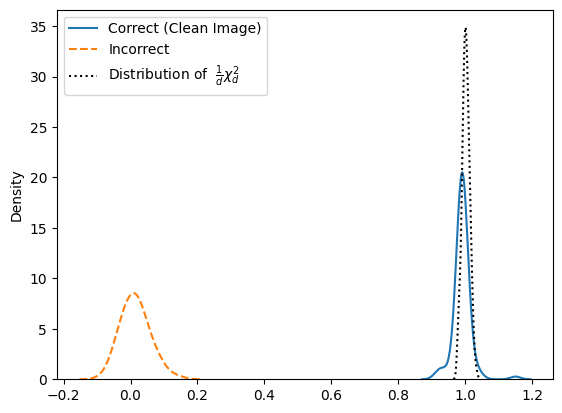

In [37]:
# Enable LaTeX rendering
plt.rcdefaults()
# Optional: specify font
# plt.rcParams['font.family'] = 'serif'

sb.kdeplot([i/d for i in test_stat], bw_adjust=1.5, label="Correct (Clean Image)")
sb.kdeplot([i/d for i in test_stat_wrong], bw_adjust=1.5, label="Incorrect", linestyle = "--")
# sb.kdeplot([i/d for i in test_stat_gauss_1], bw_adjust=1.5, label="Correct POA 1")
# sb.kdeplot([i/d for i in test_stat_gauss_3], bw_adjust=1.5, label="Correct POA 3")
# sb.kdeplot([i/d for i in test_stat_gauss_5], bw_adjust=1.5, label="Correct POA 5")
# sb.kdeplot([i/d for i in test_stat_gauss_7], bw_adjust=1.5, label="Correct POA 7")
# sb.kdeplot([i/d for i in test_stat_gauss_9], bw_adjust=1.5, label=r"Correct (N(0, 9))", linestyle=":")


# sb.kdeplot([i/d for i in test_stat_jpeg_75], bw_adjust=1.5, label="Correct (JPEG Quality 70)", linestyle="-.")
# sb.kdeplot([i/d for i in test_stat_jpeg_50], bw_adjust=1.5, label="Correct (JPEG Quality 20)", linestyle = "-.")
sb.kdeplot(chi_square_points / d, label=r"Distribution of  $\frac{1}{d} \chi^2_d$", linestyle = ":", color="black")
# plt.axvline(x=chi2.ppf(10**-20, df=d)/d, color='r', linestyle='--', label=r'Rejection Threshold @ $\alpha={10^{-20}}$')
# sb.kdeplot(gaussian_points / d)
plt.legend()

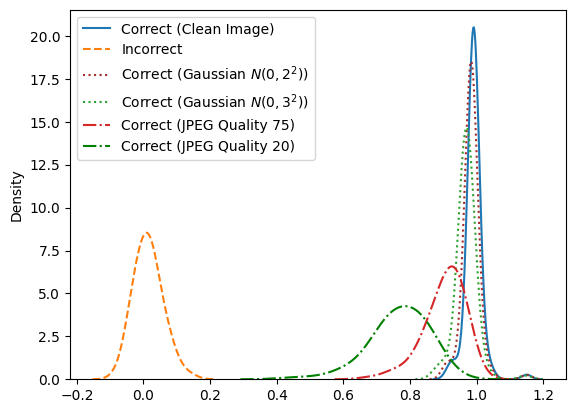

In [38]:
# Enable LaTeX rendering
plt.rcdefaults()
# Optional: specify font
# plt.rcParams['font.family'] = 'serif'

sb.kdeplot([i/d for i in test_stat], bw_adjust=1.5, label="Correct (Clean Image)")
sb.kdeplot([i/d for i in test_stat_wrong], bw_adjust=1.5, label="Incorrect", linestyle = "--")
# sb.kdeplot([i/d for i in test_stat_gauss_1], bw_adjust=1.5, label="Correct POA 1")
sb.kdeplot([i/d for i in test_stat_gauss_3], bw_adjust=1.5, label=r"Correct (Gaussian $N(0, 2^2)$)", linestyle=":", color="brown")
# sb.kdeplot([i/d for i in test_stat_gauss_5], bw_adjust=1.5, label="Correct POA 5")
# sb.kdeplot([i/d for i in test_stat_gauss_7], bw_adjust=1.5, label="Correct POA 7")
sb.kdeplot([i/d for i in test_stat_gauss_9], bw_adjust=1.5, label=r"Correct (Gaussian $N(0, 3^2)$)", linestyle=":")


sb.kdeplot([i/d for i in test_stat_jpeg_75], bw_adjust=1.5, label="Correct (JPEG Quality 75)", linestyle="-.")
sb.kdeplot([i/d for i in test_stat_jpeg_50], bw_adjust=1.5, label="Correct (JPEG Quality 20)", linestyle = "-.", color="green")

# sb.kdeplot(chi_square_points / d, label=r"Distribution of  $\frac{1}{d} \chi^2_d$", linestyle = ":")
# plt.axvline(x=chi2.ppf(10**-20, df=d)/d, color='r', linestyle='--', label=r'Rejection Threshold @ $\alpha={10^{-20}}$')
# sb.kdeplot(gaussian_points / d)
plt.legend()